In [111]:
from scipy import signal
import pandas as pd
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('ISAC3.csv')

# Filter to smaller time window
# start = pd.Timestamp('2026-03-22 3:00').timestamp()
# end = pd.Timestamp('2026-03-22 6:00').timestamp()
start = pd.Timestamp('2026-03-21 3:00').timestamp()
end = pd.Timestamp('2026-03-22 6:00').timestamp()
df = df[(df['unixTime'] >= start) & (df['unixTime'] <= end)]

# 2. Convert Unix time to datetime

df['datetime'] = pd.to_datetime(df['unixTime'], unit='s')
df = df.set_index('datetime')
# df = df.resample('1s')

# 1. Ensure index is datetime
df.index = pd.to_datetime(df.index)

# 2. Select only numeric columns (floats and ints) for the resampling
# This avoids the TypeError from string/object columns
df_numeric = df.select_dtypes(include=[np.number])

# 2. Resample to the 1s cadence
df_resampled = df_numeric.resample('1s').mean()

# 4. (Optional) If you need the string columns back,
# you can use 'first' or 'last' to grab the value from that second
df_strings = df.select_dtypes(exclude=[np.number]).resample('1s').first()

# Combine them back if necessary
df = pd.concat([df_resampled, df_strings], axis=1)

# cut off those early peaks:
# df = df[df['unixTime']>1774143000]

# SANITY CHECK: make backscatter_117 a shifted copy of backscatter_123.
# df['backscatter_117'] = df['backscatter_123'].shift(900)


Signals are best aligned at a lag of: -11 samples


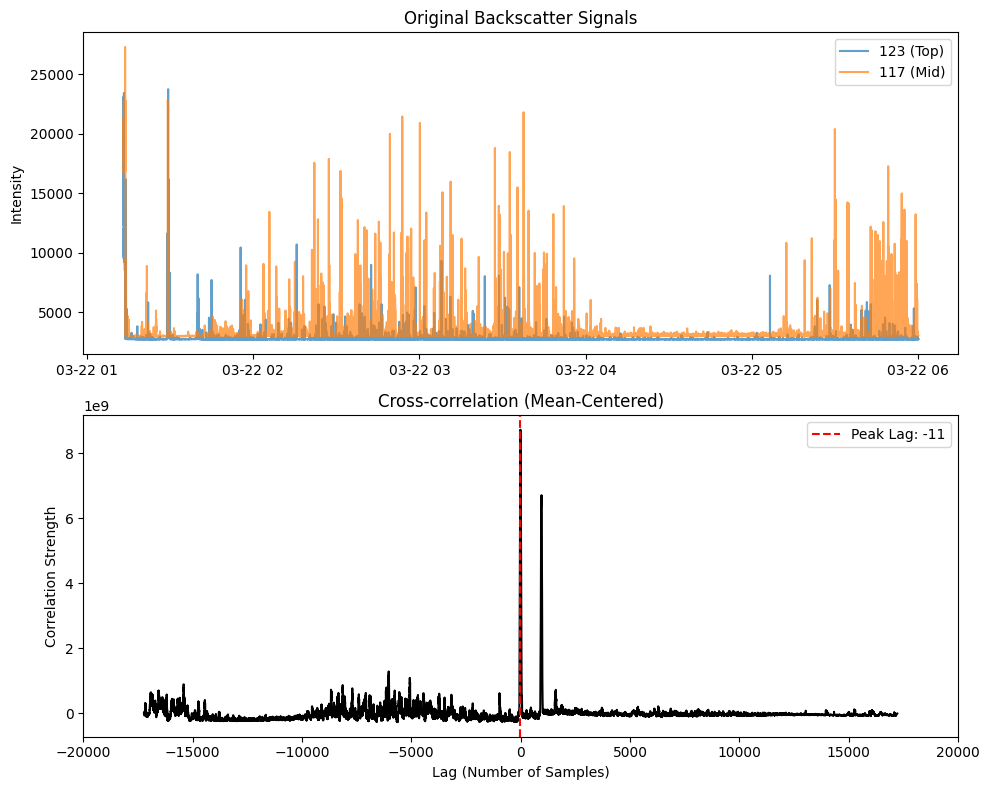

Time Offset: -11.0 seconds
Settling Velocity: -0.2727 m/s (-23563.64 m/day)


In [112]:
# cut off those early peaks:
# df = df[df['unixTime']>1774143000]

# 1. Prepare the data
# Use the new dedicated methods instead of fillna(method='...')
y1 = df['backscatter_123'].ffill().bfill()
y2 = df['backscatter_117'].ffill().bfill()
# y1 = df['ambient_filtered_123'].ffill().bfill()
# y2 = df['ambient_filtered_117'].ffill().bfill()




# Mean-center the data for a meaningful correlation peak
y1_normalized = y1 - y1.mean()
y2_normalized = y2 - y2.mean()

# 2. Calculate Correlation
correlation = signal.correlate(y1_normalized, y2_normalized, mode='full')
lags = signal.correlation_lags(len(y1), len(y2), mode='full')

# 3. Find the 'Peak' Lag
best_lag = lags[np.argmax(correlation)]
print(f"Signals are best aligned at a lag of: {best_lag} samples")

# 4. Plotting
fig, (ax_data, ax_corr) = plt.subplots(2, 1, figsize=(10, 8))

# Top Plot: Original data comparison
ax_data.plot(y1.index, y1, label="123 (Top)", alpha=0.7)
ax_data.plot(y2.index, y2, label="117 (Mid)", alpha=0.7)
ax_data.set_title("Original Backscatter Signals")
ax_data.set_ylabel("Intensity")
ax_data.legend()

# Bottom Plot: Correlation coefficients across lags
ax_corr.plot(lags, correlation, color='black')
ax_corr.axvline(best_lag, color='red', linestyle='--', label=f'Peak Lag: {best_lag}')
ax_corr.set_title("Cross-correlation (Mean-Centered)")
ax_corr.set_xlabel("Lag (Number of Samples)")
ax_corr.set_xlim([-20000, 20000])
ax_corr.set_ylabel("Correlation Strength")
ax_corr.legend()

plt.tight_layout()
plt.show()
# --- PHYSICAL PARAMETERS ---
distance_between_sensors = 3.0  # meters (adjust this)
# sampling_interval = .1          # log cadence in seconds
sampling_interval = (df.index[1] - df.index[0]).total_seconds() # ...or we just let the computer calculate it

# 1. Convert lag in 'samples' to 'seconds'
lag_seconds = best_lag * sampling_interval

# 2. Calculate Velocity (V = d / t)
if lag_seconds != 0:
    velocity = distance_between_sensors / lag_seconds
    # Convert to meters per day
    velocity_m_day = velocity * 86400

    print(f"Time Offset: {lag_seconds} seconds")
    print(f"Settling Velocity: {velocity:.4f} m/s ({velocity_m_day:.2f} m/day)")
else:
    print("Signals are perfectly synchronized (no measurable lag).")